# Uncovering Pancreatic Cell Types with Hierarchical Density-Based Clustering


Sections:
1. installation
2. imports and setup
3. data loading / preparation
4. model construction and fitting
5. exploration of condensed trees
6. visualizing and evaluating hierarchical partition
5. extracting and evaluating flat partition


A key step in the analysis of single-cell RNA sequencing (scRNA-seq) datasets is clustering. While state-of-the-art methods group cells with similar profiles, they cannot recapitulate hierarchical dependencies among cells. To address this and show the value of hierarchical clustering in scRNA-seq, we use GraphHDBSCAN* in a well-known, beginner-friendly setup inspired by [single-cell-best-practices](https://www.sc-best-practices.org/).

## Installation

Install required package(s):

```bash
!pip install git+https://github.com/Campello-Lab/GraphHDBSCAN.git
```

## Imports and setup

In [2]:
import pooch
pooch.get_logger().setLevel("WARNING")
import scanpy as sc
import matplotlib.pyplot as plt
# Suppress verbose logging from Scanpy
sc.settings.verbosity = 0

# Set figure parameters for clean, minimal plots
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False)
from coresg_graphhdbscan import GraphCoreSGHDBSCAN
import networkx as nx
from coresg_graphhdbscan.ground_truth_pies import (
     plot_condensed_tree_ground_truth_pies,
     resolve_condensed_tree,
 )

import pandas as pd
from sklearn.metrics import adjusted_rand_score as ARI

## Load and prepare the dataset

We perform clustering on the Human Pancreas Dataset, containing pancreatic cells from 4 healthy donors {cite:p}`Baron2016`, and being often used for various clustering benchmarking studies. Dataset was downloaded from [scRNAseq](https://bioconductor.org/packages/release/data/experiment/html/scRNAseq.html) Bioconductor package and processed to AnnData object, and next deposited to [Zenodo](https://zenodo.org/records/23238427).

In [3]:
path = pooch.retrieve(
    url="https://zenodo.org/records/23238427/files/BaronPancreasData_raw.h5ad?download=1",
    known_hash=None,              # fill in after the first run, see below
    fname="BaronPancreasData_raw.h5ad",
)
adata = sc.read_h5ad(path)

In [4]:
adata

AnnData object with n_obs × n_vars = 8569 × 18845
    obs: 'donor', 'label'
    var: 'originalName'
    layers: None (.X)

As described in {cite:p}`szmigiel2025` benchmarking study, we first preprocess the raw count matrix using a standard pipeline and then select the 1,000 most highly variable genes. This step retains the genes that capture the most meaningful variation between cell types.

In [5]:
sc.pp.filter_cells(adata, min_genes=100, inplace=True)
sc.pp.filter_genes(adata, min_cells=(len(adata.obs)*0.1), inplace=True)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=None, key_added='norm_factor')  
sc.experimental.pp.highly_variable_genes(adata, n_top_genes=1000, layer='counts')
sc.pp.log1p(adata)
adata_hvg= adata[:, adata.var["highly_variable"]]

In [6]:
adata_hvg

View of AnnData object with n_obs × n_vars = 8569 × 1000
    obs: 'donor', 'label', 'n_genes', 'norm_factor'
    var: 'originalName', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'hvg', 'log1p'
    layers: None (.X), 'counts'

## Model construction and fitting

Next, we can call the `GraphCoreSGHDBSCAN` object for determining how the density search will be performed. Chosing multiple values for `min_samples` is useful for comparing different density settings in one run. We set `no_noise = True` to force noise points propagation to their closest clusters. Since GraphHDBSCAN, is a graph-based algorithm, the preceeding step for data preparation is the choice of graph. We chose the default Scanpy graph construction (`n_neighbors = 15`, `sim_graph_method = 'sc_umap'`). 

In [7]:
g = GraphCoreSGHDBSCAN(
    min_samples=range(2,50),
    sim_graph_method="sc_umap",
    n_neighbors=15,
    no_noise = True,
)

In [8]:
g.fit(adata_hvg.X)

[TIMER] GraphCoreSGHDBSCAN._create_similarity_sparse: 12.7178s


[TIMER] GraphCoreSGHDBSCAN._wss_similarity_sparse: 0.3439s
[TIMER] GraphCoreSGHDBSCAN.similarity_to_dissimilarity_sparse: 0.2004s


[TIMER] _build_graph_distance:connectivity_check: 0.0427s
[TIMER] GraphCoreSGHDBSCAN._build_graph_distance: 13.3053s


[CORE-SG] (sparse) CORE-SG graph has 284520 edges (284520 real + 0 bridges) across 1 component(s)
[TIMER] fit:coresg_.fit_from_sparse_graph: 3.4460s
[CORE-SG] m= 2: MST+tree+labels in 0.1293s


[CORE-SG] m= 3: MST+tree+labels in 0.1337s
[CORE-SG] m= 4: MST+tree+labels in 0.1365s


...

[CORE-SG] m=43: MST+tree+labels in 0.1155s
[CORE-SG] m=44: MST+tree+labels in 0.1168s


[CORE-SG] m=45: MST+tree+labels in 0.1167s
[CORE-SG] m=46: MST+tree+labels in 0.1135s


[CORE-SG] m=47: MST+tree+labels in 0.1065s
[CORE-SG] m=48: MST+tree+labels in 0.1045s


[CORE-SG] m=49: MST+tree+labels in 0.1043s
[TIMER] fit:coresg_.run: 5.9435s
[TIMER] GraphCoreSGHDBSCAN.fit: 22.6949s


GraphCoreSGHDBSCAN(min_samples=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], sim_graph_method='sc_umap', metric='euclidean', n_neighbors=15, min_cluster_size=None, save_models=False, fitted=True, n_models=48, n_condensed_trees=48, n_label_sets=48)

## Exploration of condensed trees

After getting the results, we investigate a couple of condensed trees generated with GraphHDBSCAN*.

<Figure size 3000x1800 with 0 Axes>

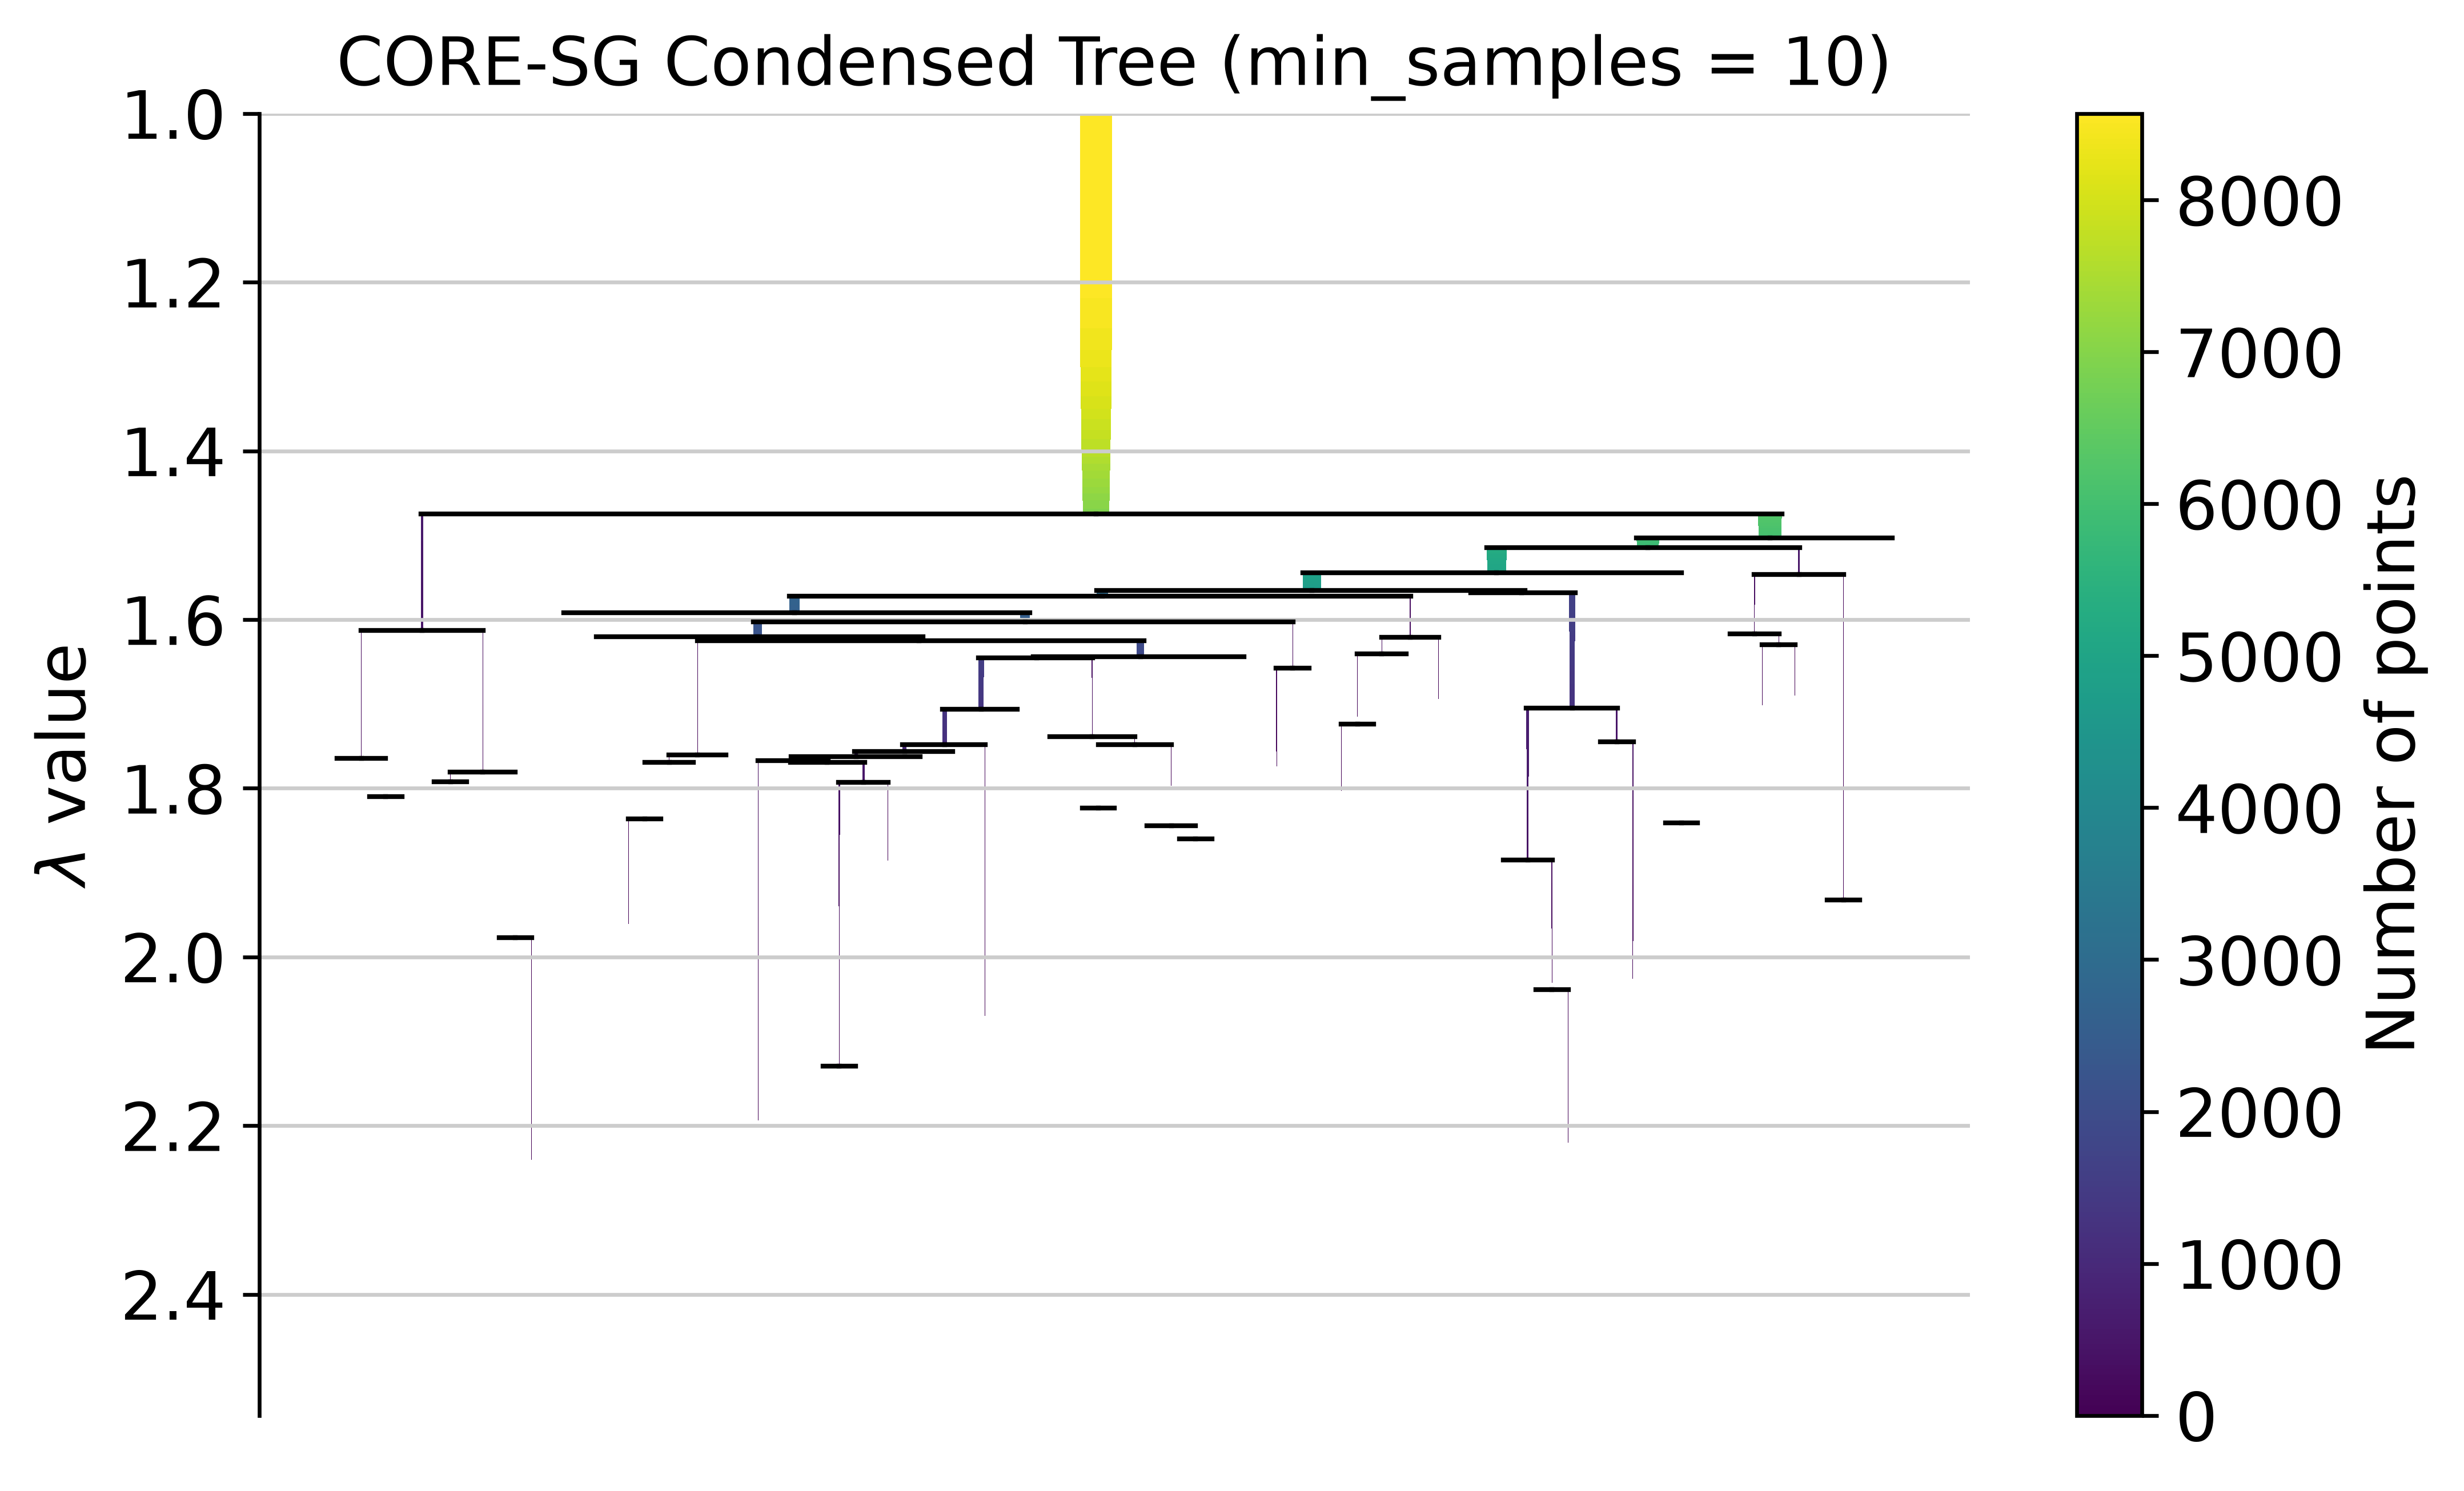

<Axes: title={'center': 'CORE-SG Condensed Tree (min_samples = 10)'}, ylabel='$\\lambda$ value'>

In [9]:
g.plot_condensed_tree(10)

<Figure size 3000x1800 with 0 Axes>

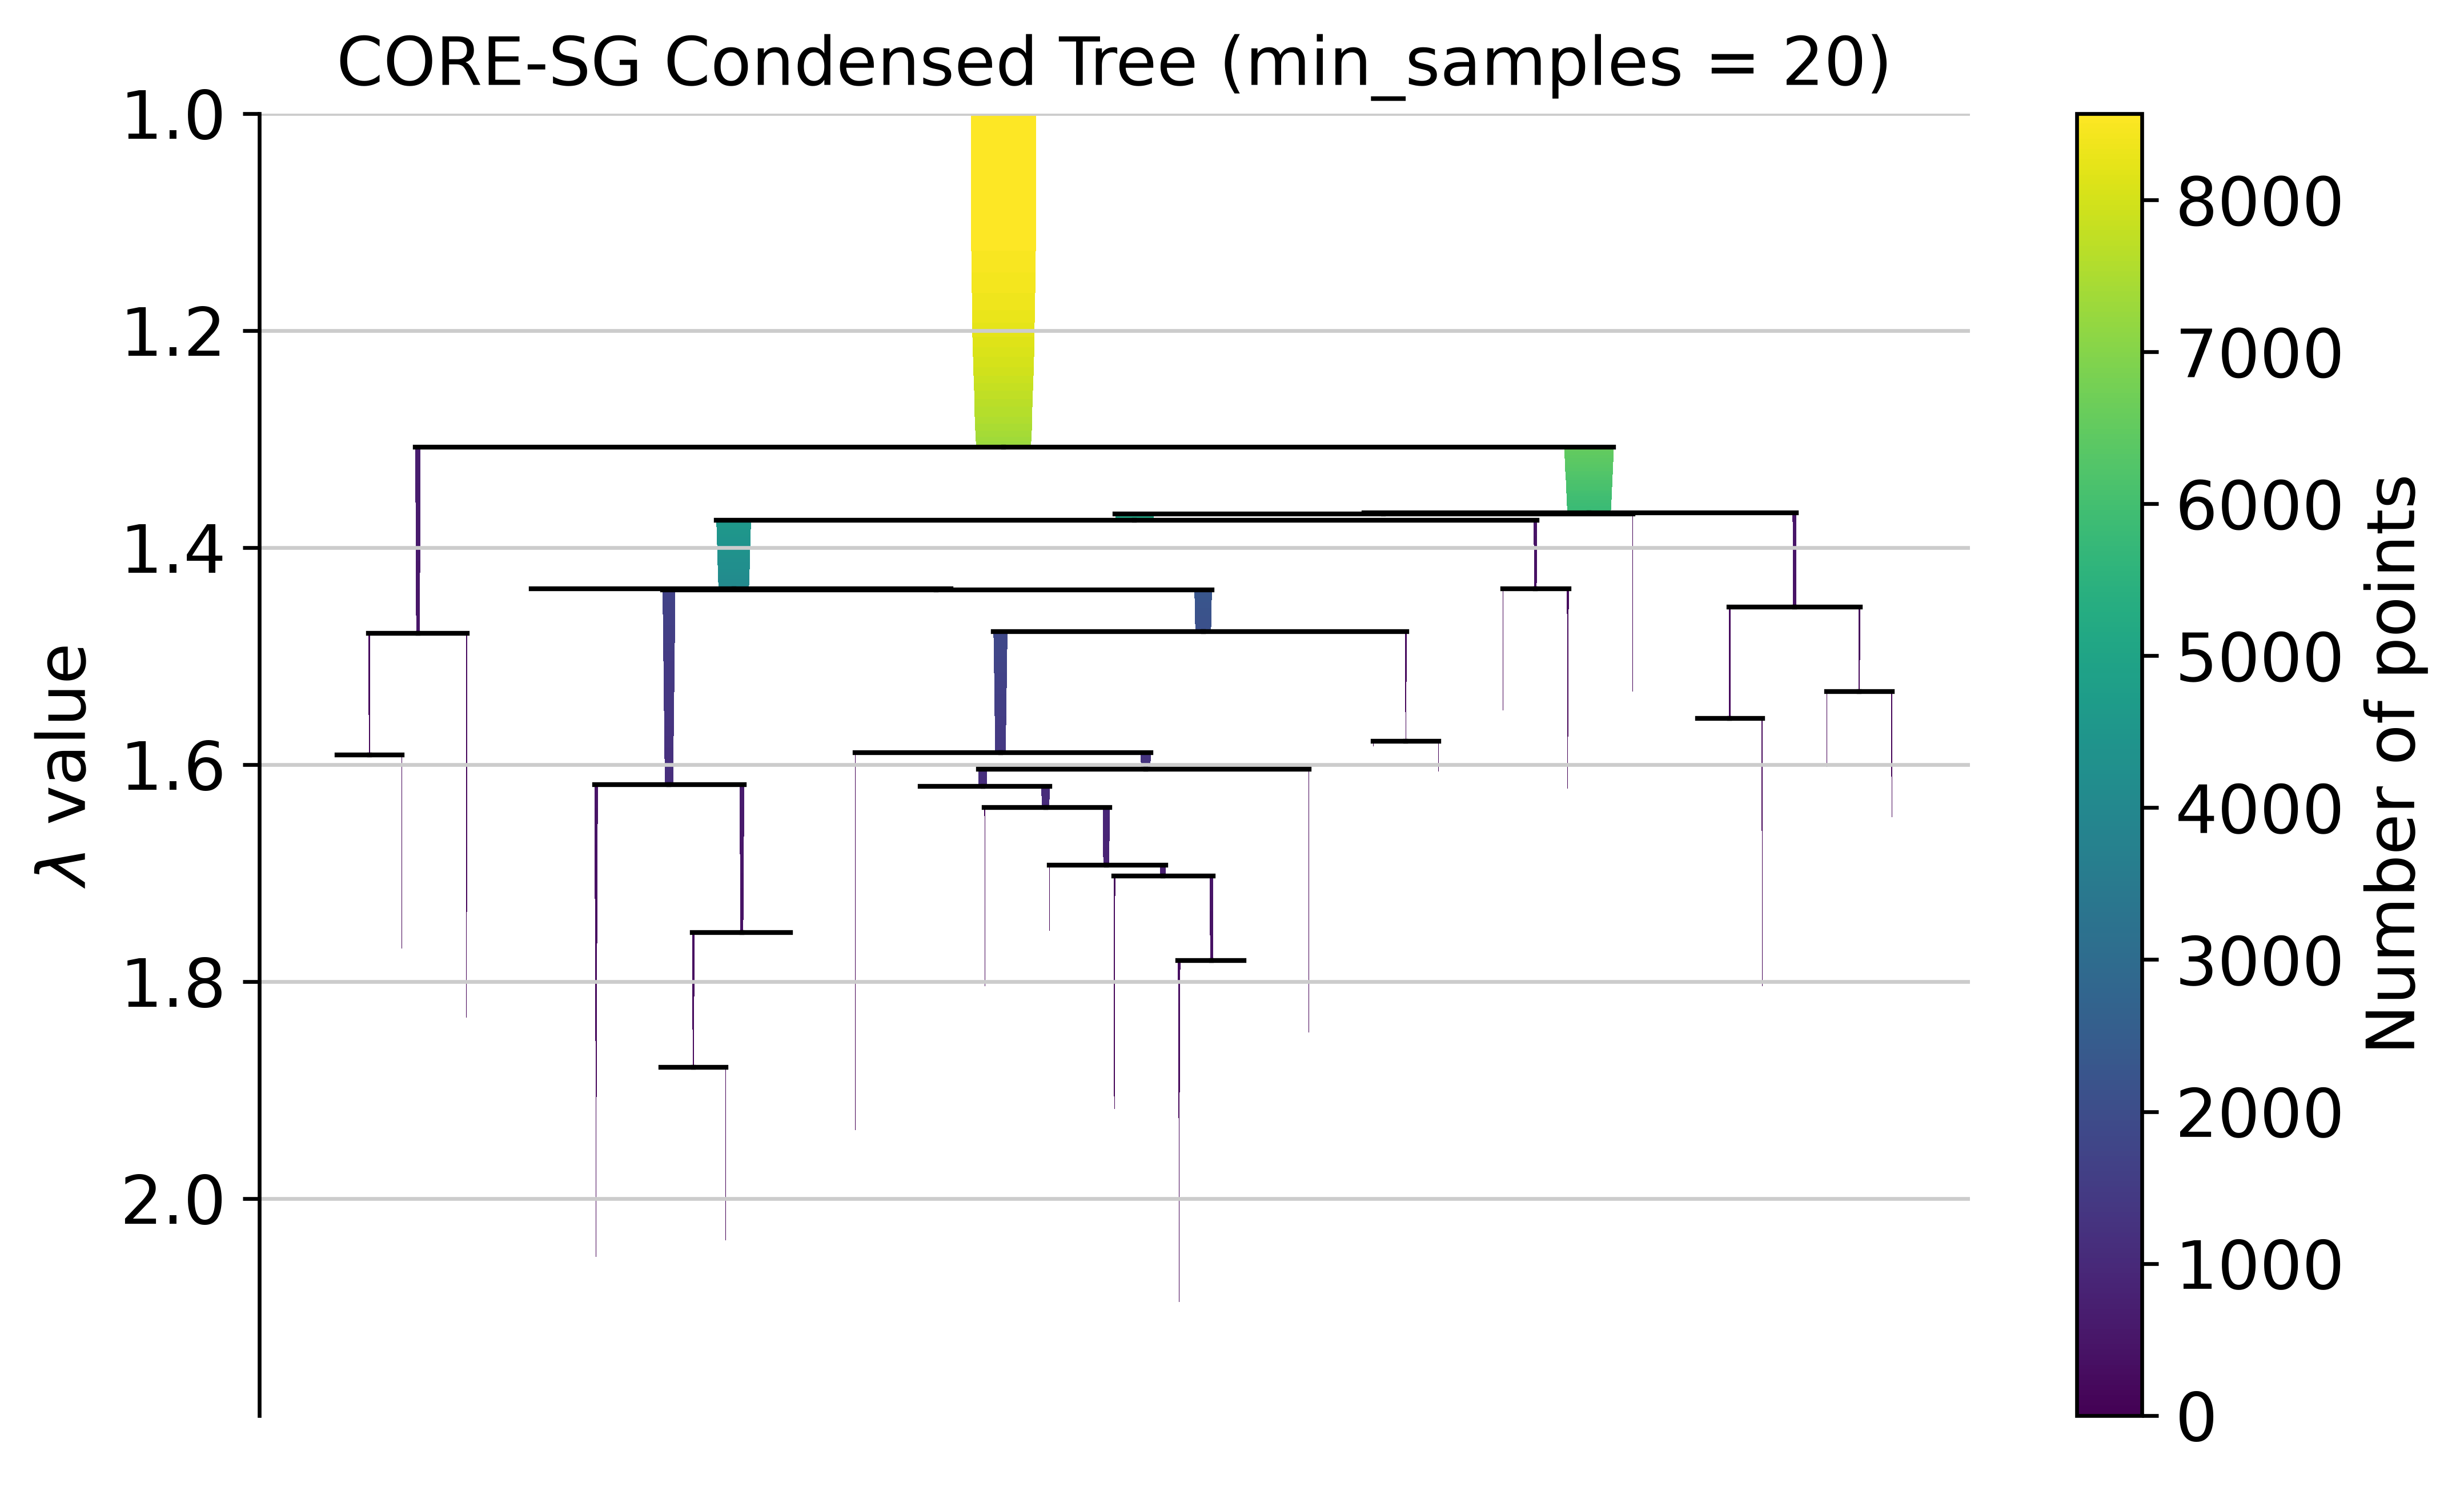

<Axes: title={'center': 'CORE-SG Condensed Tree (min_samples = 20)'}, ylabel='$\\lambda$ value'>

In [10]:
g.plot_condensed_tree(20)

<Figure size 3000x1800 with 0 Axes>

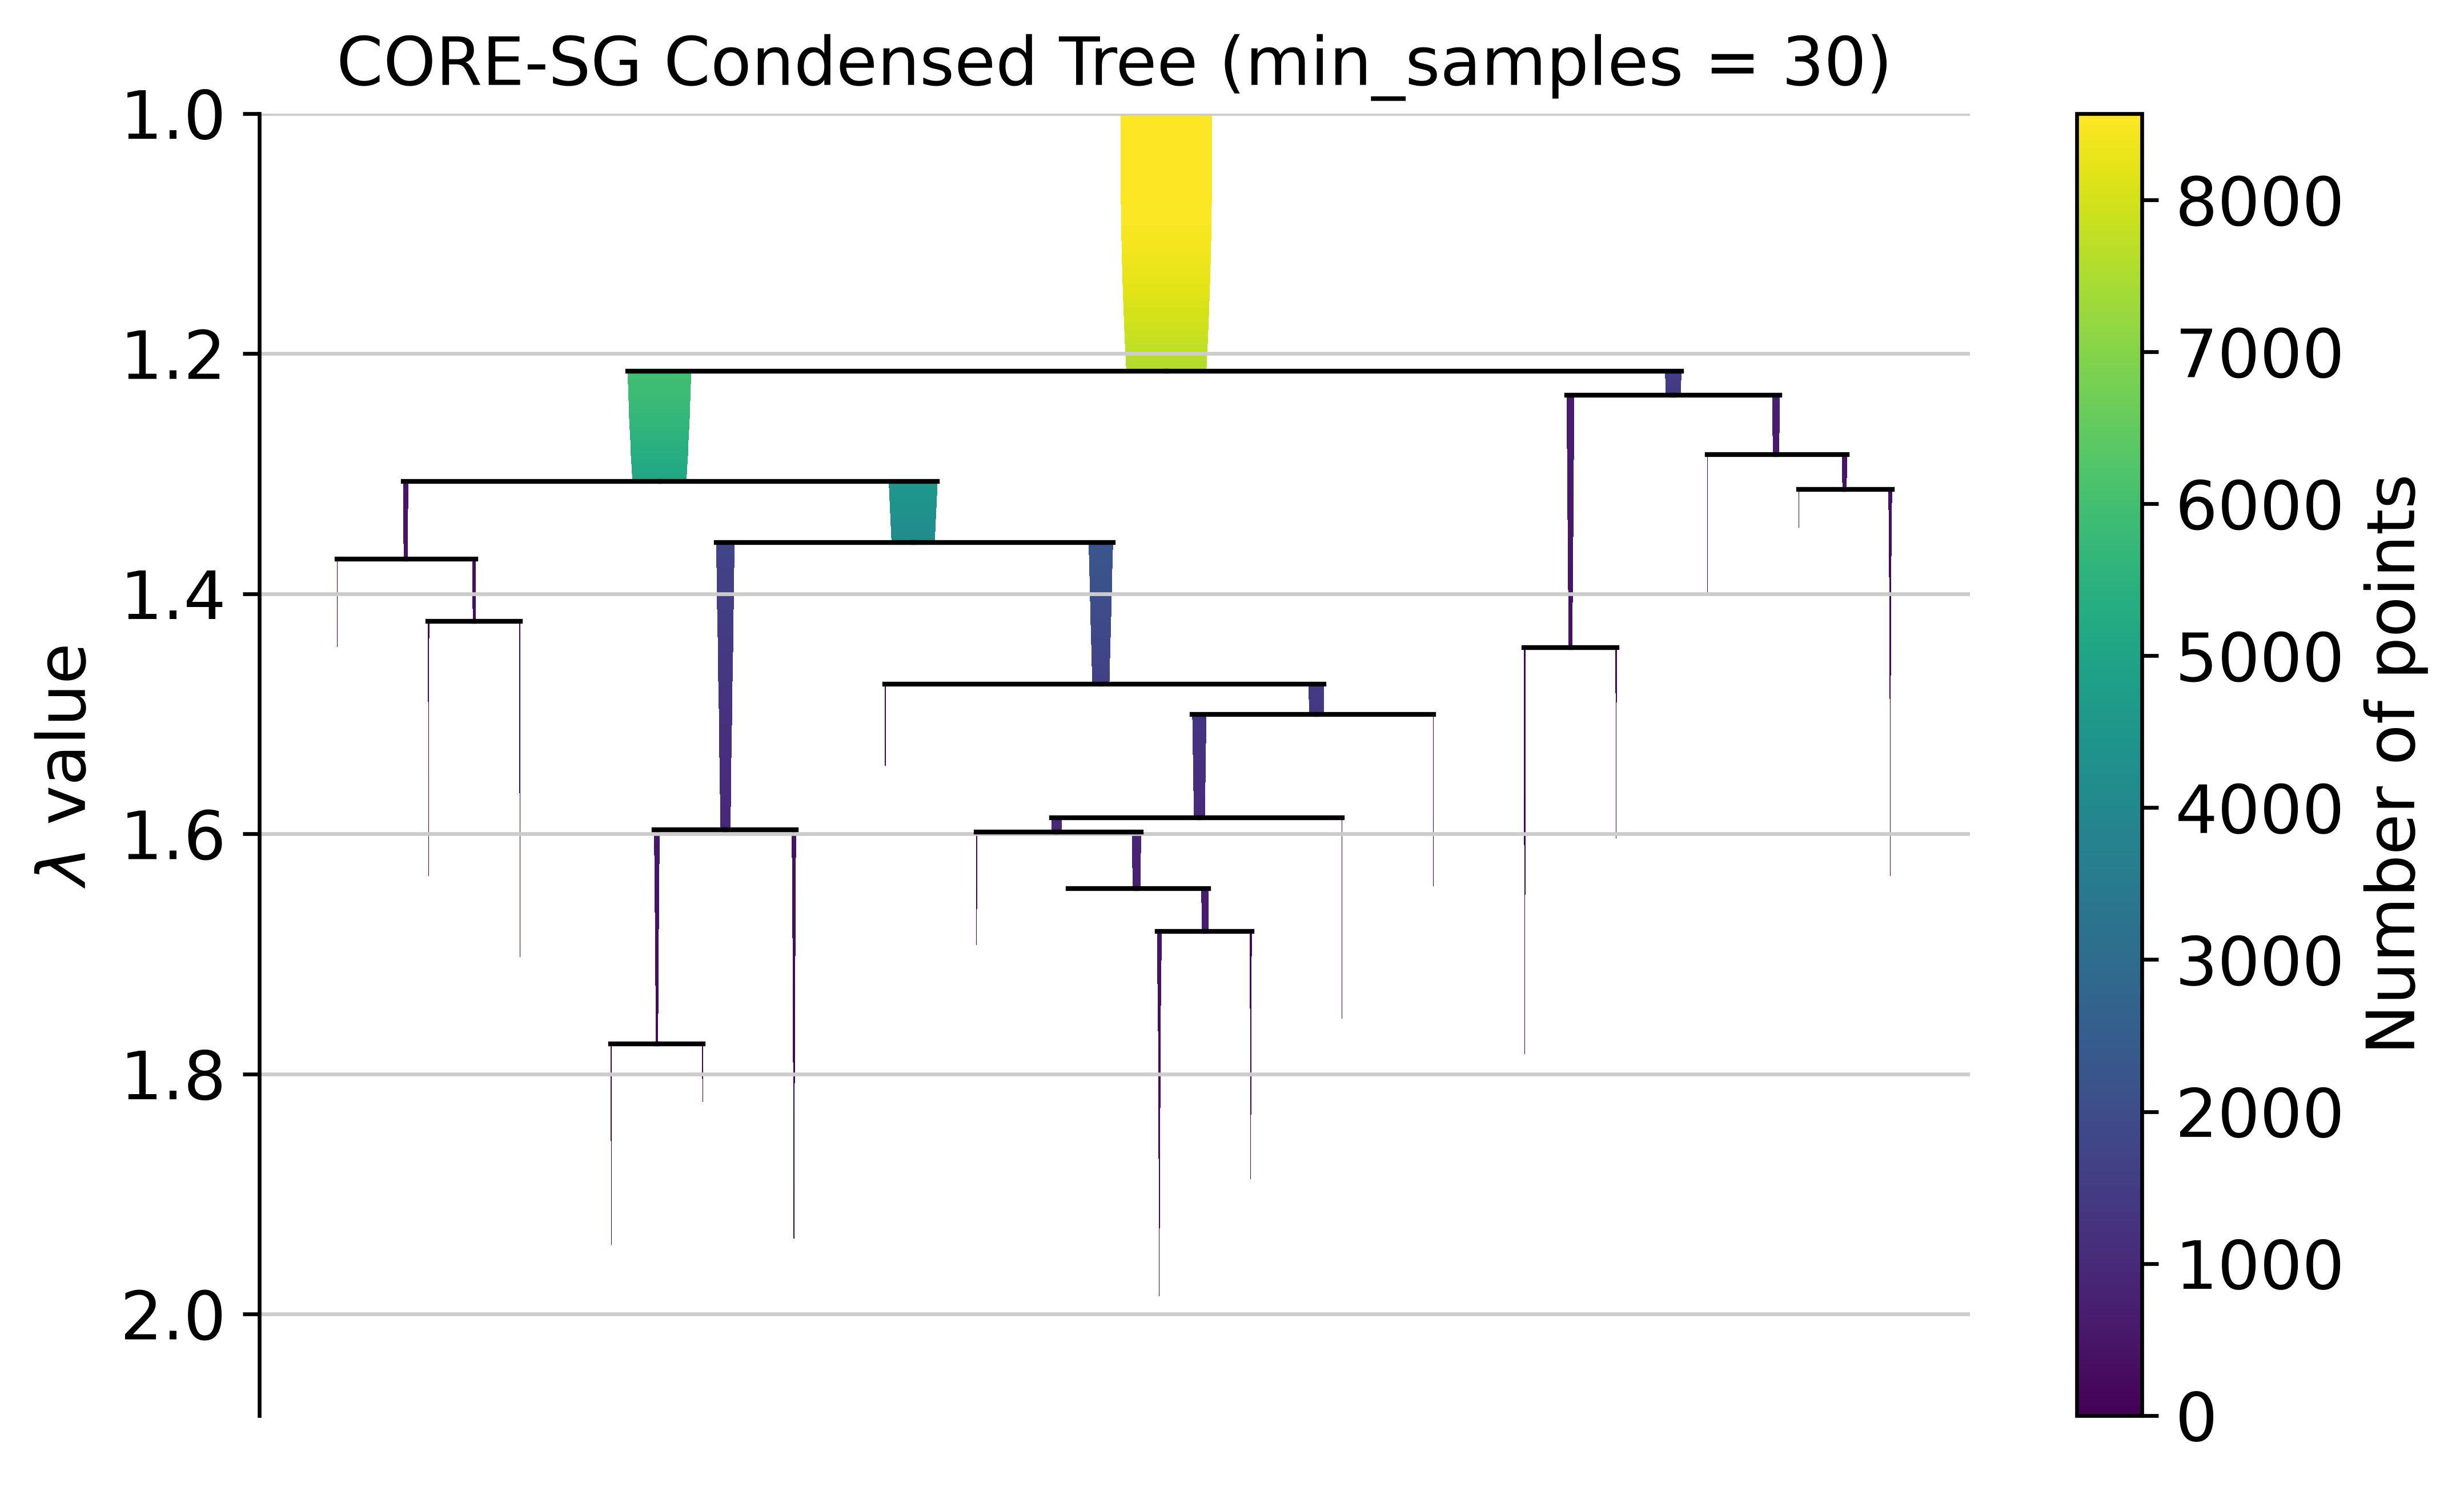

<Axes: title={'center': 'CORE-SG Condensed Tree (min_samples = 30)'}, ylabel='$\\lambda$ value'>

In [11]:
g.plot_condensed_tree(30)

<Figure size 3000x1800 with 0 Axes>

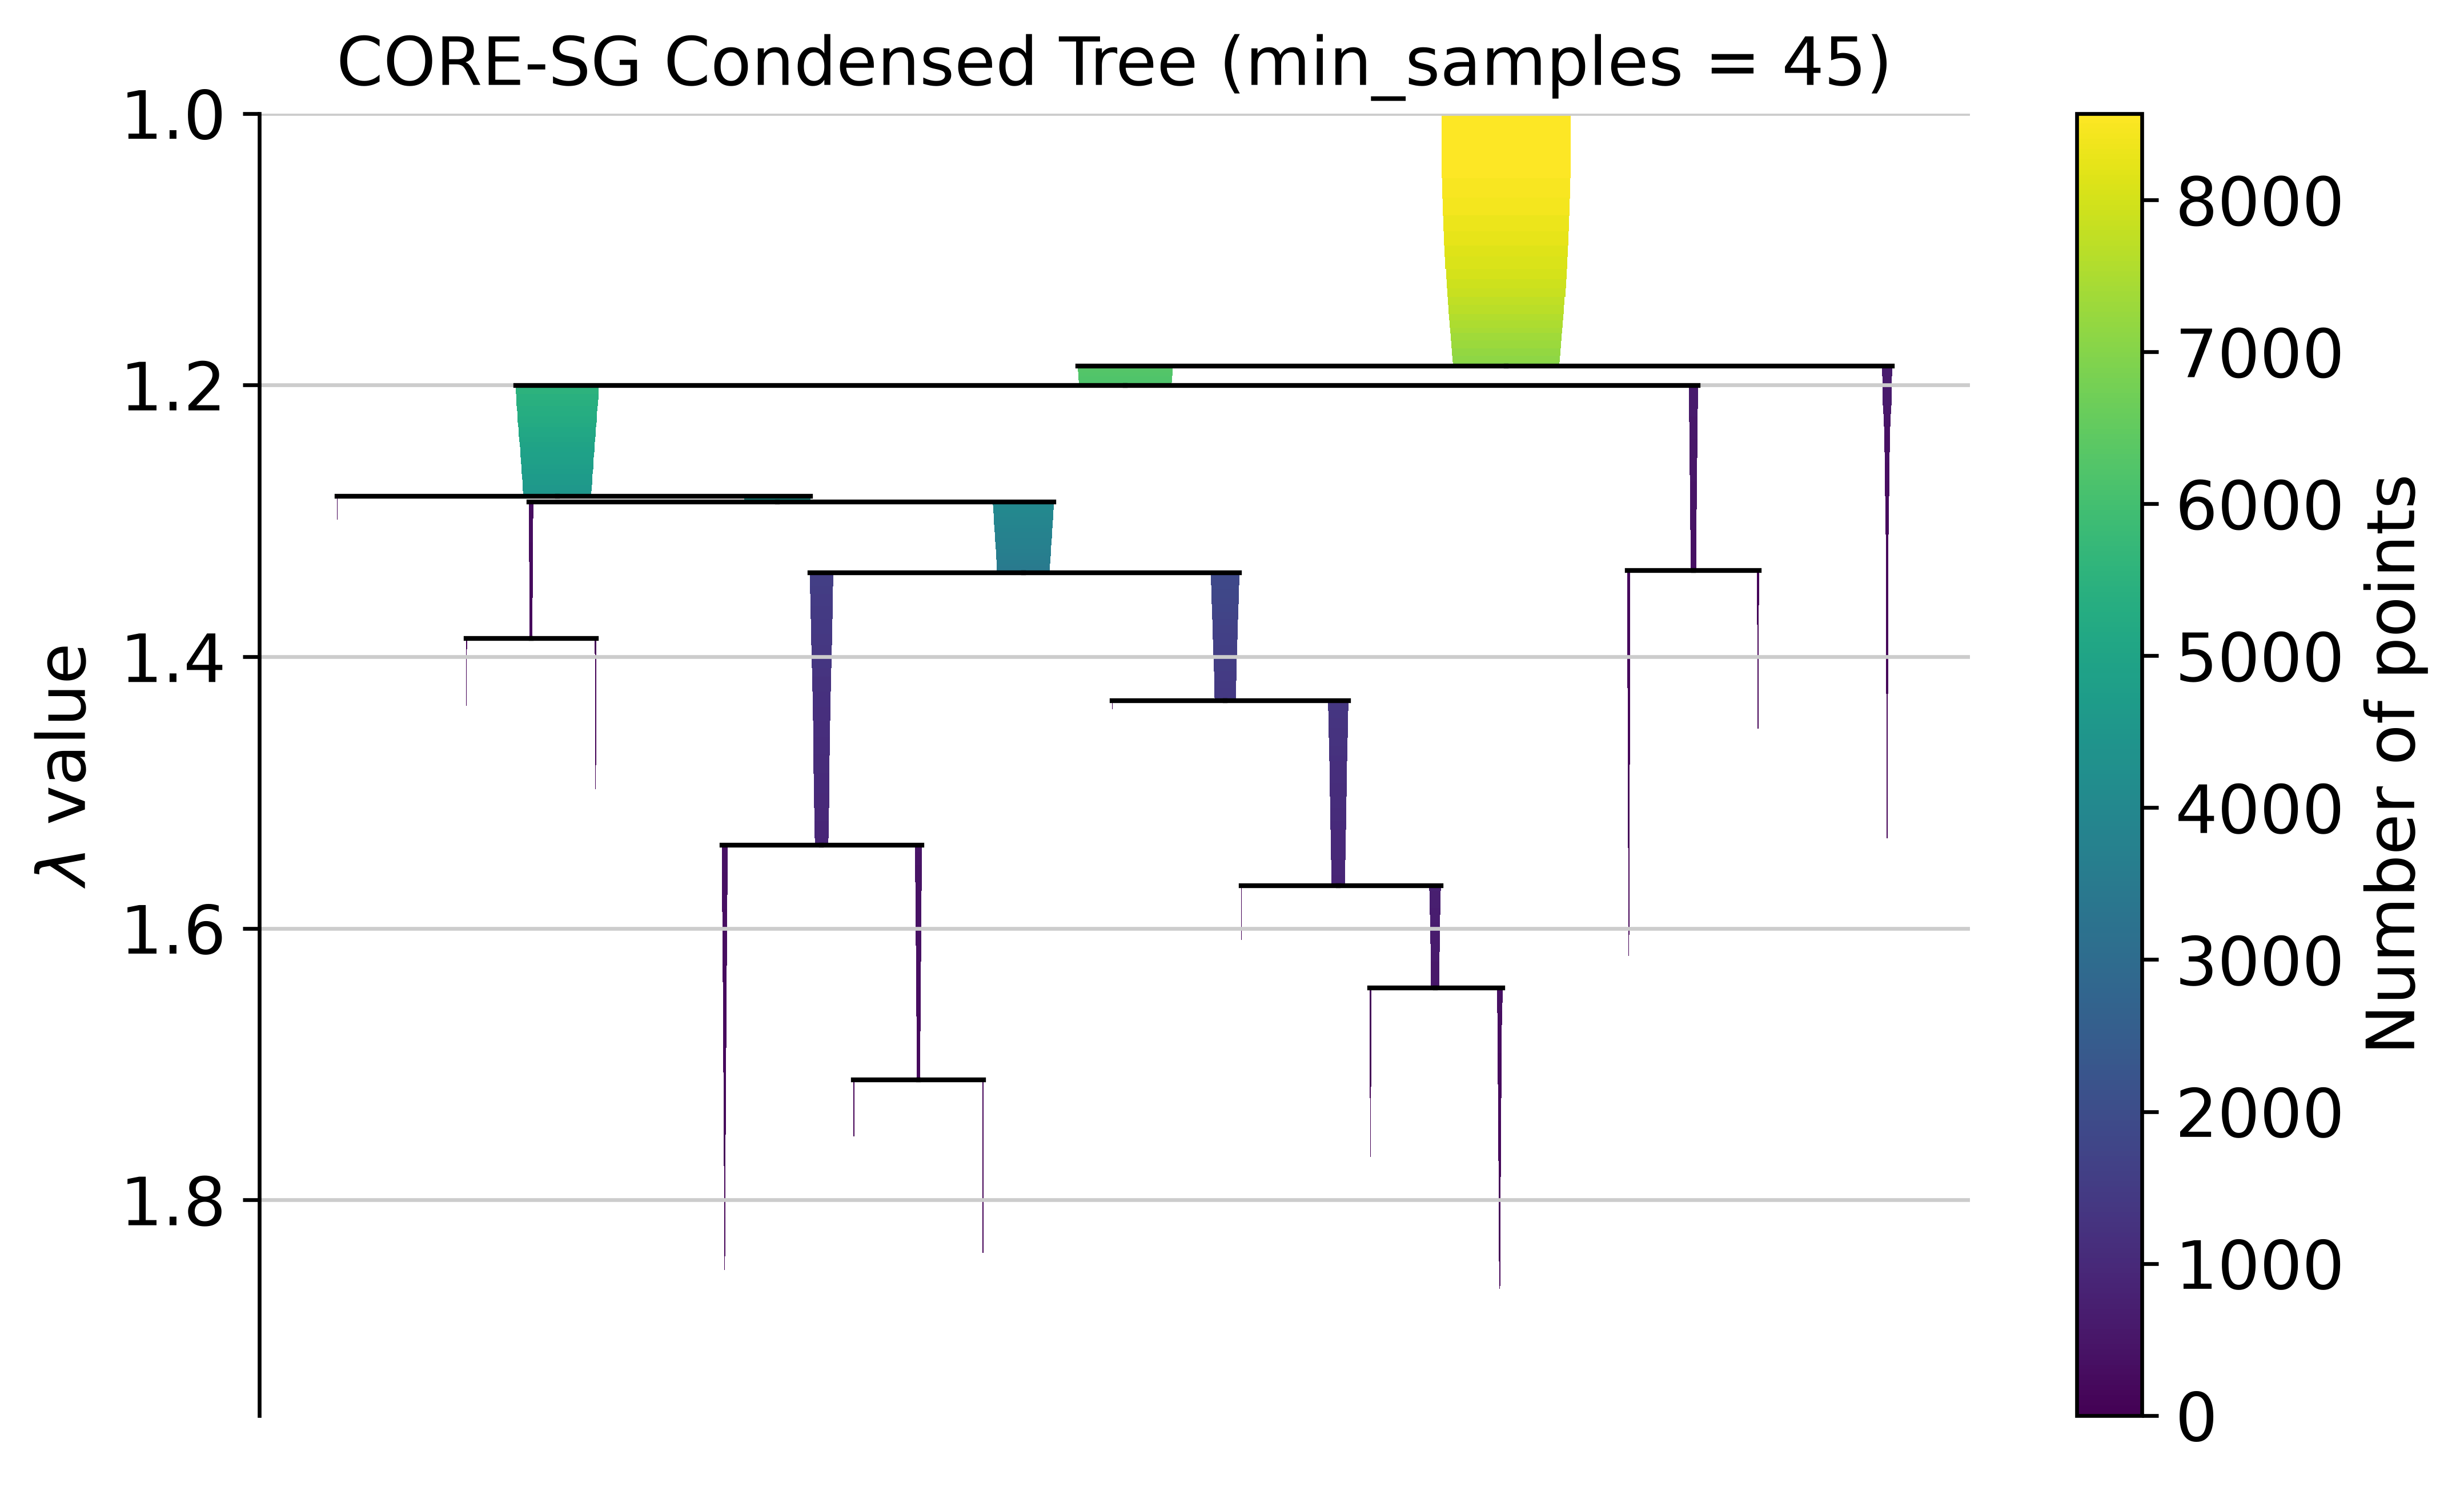

<Axes: title={'center': 'CORE-SG Condensed Tree (min_samples = 45)'}, ylabel='$\\lambda$ value'>

In [12]:
g.plot_condensed_tree(45)

In a healthy pancreas, the tissue is anatomically and functionally divided into two distinct compartments: the endocrine and the exocrine pancreas. Not knowing a lot about a dataset, it might be reasonable to choose the condensed tree that provides the first split into these two major compartments. This coarse boundary should be recovered without much “effort” from the clustering algorithm. We would also expect the exocrine branch to split earlier than the endocrine one. Endocrine subtypes are functionally closer to one another than the exocrine subpopulations are, so they should only separate at higher density levels.

We can clearly see that this first split into two groups happens at around λ = 1.2 for the condensed tree built with `min_samples = 30`. Looking at the next splits within these two branches, the exocrine branch divides at a noticeably lower λ than the endocrine branch, which matches the expected biological pattern.

For `min_samples = 20`, the first split places most of the dataset into the right-hand branch. For `min_samples = 45`, the first split also places most of the cells into the right branch, and a small cluster separates off immediately afterwards. Since `min_samples = 30` gives the most balanced division into the two main compartments at the first split, we continue our analysis with this condensed tree.

## Extracting and evaluating flat partition

We can extract the flat partition for condensed tree built with `min_samples = 30`. GraphHDBSCAN*, although proposed for hierarchical clustering, makes it possible and simple to extract flat partition. 

In [13]:
lab = g.labels_for(30)

[TIMER] GraphCoreSGHDBSCAN.reassign_noise_via_mst: 0.0138s
[TIMER] GraphCoreSGHDBSCAN.labels_for: 0.1400s


In [14]:
adata_hvg.obs['ghdbscan'] = lab
adata_hvg.obs['ghdbscan'] = adata_hvg.obs['ghdbscan'].astype('category')


Next, we compare extracted partition with the ground truth labels found in a dataset.

In [15]:
ARI(adata_hvg.obs['label'], adata_hvg.obs['ghdbscan'])

0.7340035479371093

## Visualizing and evaluating hierarchical partition

To evaluate the unsupervised choice of the hierarchy, we can overlay ground truth labels on top of the condensed tree.

In [16]:
fig, ax = plot_condensed_tree_ground_truth_pies(
    g,                      # your fitted GraphCoreSGHDBSCAN
    y_true=adata_hvg.obs["label"],  # your ground-truth column
    m=30,                       # min_samples tree to plot
    min_node_size=15,           # only for visualization purposes
)

The condensed tree recovers the expected biology. The first split separates the exocrine compartment (acinar and ductal cells, shown in blue and red) from the remaining cells, which comprise the endocrine cell types along with a few minor, non-pancreas-specific populations. Within this left branch, endothelial and stellate cells are the next to separate from the endocrine cells. Among the endocrine subtypes, alpha cells split off first, and the remaining subtypes are then cleanly resolved further down the branch.

# References

```{bibliography}
:filter: docname in docnames
```